# 4.0 Modelado

Este notebook entrena los modelos que permiten estudiar los perfiles de resiliencia académica. La lógica reutilizable se encuentra en `src/`, de modo que el notebook, la línea de comandos y el dashboard utilicen exactamente las mismas reglas.

Los clusters se construyen para estudiantes del cuartil inferior del INSE usando contexto familiar y trayectoria. Puntaje, percentil, INSE y resiliencia se reservan para la evaluación.

## 1. Ejecución reproducible del pipeline

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = Path.cwd() if Path('src').exists() else Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.make_dataset import default_paths
from src.models.train_model import train_clustering_pipeline

sns.set_theme(style='whitegrid')
paths = default_paths()

In [2]:
result = train_clustering_pipeline(
    clean_path=paths['clean_data'],
    cluster_output_path=paths['cluster_data'],
    bundle_path=paths['bundle'],
    summary_path=paths['summary'],
    random_state=42,
)
df_model = result['data']
summary = result['summary']
print(f'Estudiantes modelados: {len(df_model):,}')
print(f'Umbral de bajo INSE: {summary["population"]["inse_threshold"]:.2f}')
print(f'Estudiantes resilientes: {summary["population"]["resilient_students"]:,}')

Estudiantes modelados: 61,943
Umbral de bajo INSE: 42.77
Estudiantes resilientes: 2,208


## 2. Preparación de variables

Las variables ordinales se estandarizan; los bienes y columnas one-hot se mantienen como 0/1. Las categorías con menos del 0,5% se agrupan como `OTRAS CATEGORÍAS`. Se reconocen las dos formas observadas de `Sin Estrato`.

In [3]:
display(result['rare_summary'].query('categorias_agrupadas > 0'))
print(f'Variables entregadas a PCA: {summary["training"]["feature_count"]}')

,variable,categorias_agrupadas,registros_afectados
0,fami_ocupacionmadre,3,378
1,fami_ocupacionpadre,2,259
2,fami_trabajolabormadre,5,551
3,fami_trabajolaborpadre,6,957


Variables entregadas a PCA: 101


## 3. Selección y entrenamiento de K-Means

Se comparan porcentajes de varianza PCA entre 70% y 90% y valores de `k` entre 3 y 10. Se descartan soluciones donde un solo cluster contiene más del 40% y se prioriza Silhouette, usando Davies-Bouldin como segundo criterio. El modelo final usa 30 inicializaciones.

,varianza_pca,componentes,k,silhouette,davies_bouldin,cluster_mayor_pct
1,0.70,10,4,0.170,1.718,34.669
8,0.80,15,3,0.164,1.952,55.480
2,0.70,10,5,0.158,1.902,30.032
9,0.80,15,4,0.144,2.016,48.662
7,0.70,10,10,0.135,2.052,18.230
3,0.70,10,6,0.132,2.330,28.898
5,0.70,10,8,0.130,1.991,23.063
4,0.70,10,7,0.117,2.079,27.317
6,0.70,10,9,0.115,2.164,19.318
16,0.85,19,3,0.114,2.322,38.335


Configuración seleccionada:


,varianza_pca,componentes,k,silhouette,davies_bouldin,cluster_mayor_pct
1,0.7,10.0,4.0,0.17,1.718,34.669


,resultado
silhouette,0.167
davies_bouldin,1.719
calinski_harabasz,11734.545


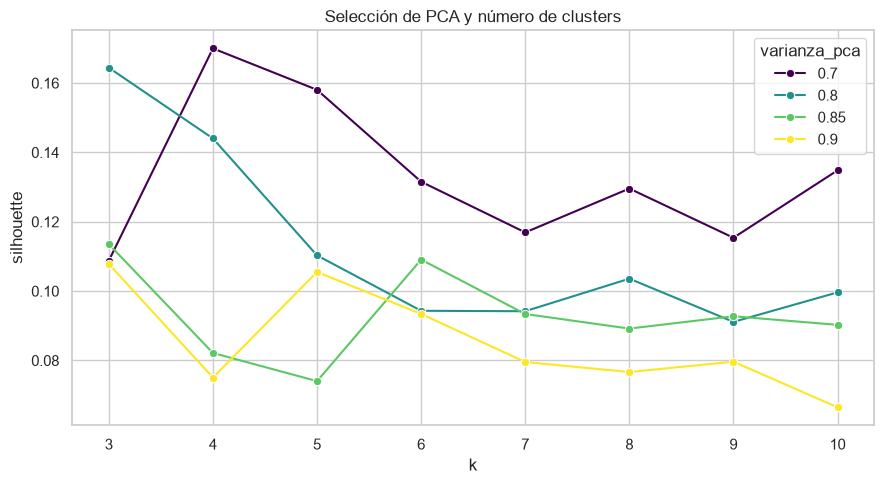

In [4]:
display(result['kmeans_search'].sort_values('silhouette', ascending=False).head(10).round(3))
print('Configuración seleccionada:')
display(result['best_kmeans'].to_frame().T.round(3))
display(pd.Series(summary['kmeans']['metrics'], name='resultado').round(3).to_frame())

plt.figure(figsize=(9, 5))
sns.lineplot(data=result['kmeans_search'], x='k', y='silhouette',
             hue='varianza_pca', marker='o', palette='viridis')
plt.title('Selección de PCA y número de clusters')
plt.tight_layout()
plt.show()

K-Means conserva cerca del 70% de la varianza en 10 componentes y forma cuatro perfiles amplios. La selección evita una segmentación excesivamente fragmentada y mantiene tamaños útiles para el análisis.

## 4. Selección y entrenamiento de DBSCAN

DBSCAN trabaja con tres componentes PCA estandarizadas mediante `whiten=True` y una muestra de 30.000 estudiantes. Se prueban combinaciones de `min_samples` y percentiles de distancia, limitando ruido, cantidad de clusters y concentración del grupo dominante.

In [5]:
display(result['dbscan_search'].round(3))
print('Configuración seleccionada:')
display(result['best_dbscan'].to_frame().T.round(3))
display(pd.Series(summary['dbscan']['metrics'], name='resultado').round(3).to_frame())

,min_samples,percentil_distancia,eps,clusters,ruido_pct,cluster_mayor_pct,silhouette,davies_bouldin
0,30,0.90,0.138,13,6.670,52.495,0.382,0.556
1,30,0.92,0.160,15,5.050,51.971,0.362,0.579
2,30,0.94,0.189,13,3.420,51.163,0.371,0.618
3,30,0.96,0.234,12,2.180,50.872,0.325,0.759
4,40,0.90,0.156,12,6.547,52.796,0.383,0.603
5,40,0.92,0.181,14,4.873,51.882,0.342,0.589
6,40,0.94,0.215,11,3.300,51.462,0.373,0.670
7,40,0.96,0.268,8,2.213,50.897,0.387,0.893
8,50,0.90,0.172,6,6.960,53.035,0.416,0.709
9,50,0.92,0.201,11,5.077,52.042,0.376,0.633


Configuración seleccionada:


,min_samples,percentil_distancia,eps,clusters,ruido_pct,cluster_mayor_pct,silhouette,davies_bouldin
8,50.0,0.9,0.172,6.0,6.96,53.035,0.416,0.709


,resultado
silhouette,0.423
davies_bouldin,0.709
calinski_harabasz,9593.252


## 5. Perfiles y artefactos exportados

Además del CSV con etiquetas, se guarda un bundle que contiene el escalador ordinal, categorías, orden de variables, PCA y modelos. Esto permite reproducir el procesamiento y asignar perfiles K-Means a registros nuevos. DBSCAN se conserva para reproducir el análisis, pero no ofrece predicción directa para casos nuevos.

In [6]:
cluster_profiles = pd.DataFrame(summary['kmeans']['profiles'])
display(cluster_profiles.round(2))
print('Archivos generados:')
for name, path in result['paths'].items():
    print(f'- {name}: {Path(path).resolve()}')

,cluster_kmeans,estudiantes,puntaje_promedio,percentil_promedio,inse_promedio,bienes_promedio,resilientes,tasa_resiliencia,porcentaje_poblacion,participacion_resilientes,indice_concentracion,nombre
0,0,21541,133.95,35.95,35.73,2.83,508,2.36,34.78,23.01,0.66,Mayor vulnerabilidad observada
1,1,19417,138.39,40.96,38.88,3.22,752,3.87,31.35,34.06,1.09,Mayor disponibilidad material
2,2,5272,137.65,40.24,37.56,2.73,167,3.17,8.51,7.56,0.89,Preparación académica reportada
3,3,15713,140.16,43.37,38.93,2.70,781,4.97,25.37,35.37,1.39,Mayor capital educativo familiar


Archivos generados:
- cluster_data: /Users/fermin/Documents/GitHub/colombia-higher-ed-assessment-analysis/data/processed/saber_pro_2024_clusters_estudiantes.csv
- bundle: /Users/fermin/Documents/GitHub/colombia-higher-ed-assessment-analysis/models/saber_pro_clustering_bundle.joblib
- summary: /Users/fermin/Documents/GitHub/colombia-higher-ed-assessment-analysis/models/model_summary.json


## 6. Resultado

El pipeline deja un dataset de estudiantes con bajo INSE y sus clusters, un bundle reproducible para inferencia K-Means y un resumen JSON para el dashboard. La interpretación académica se desarrolla en `5.0-evaluation.ipynb`.